# <center>**Source Model**<center>

**Libraries**

In [1]:
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt

import mbloodmoon as bm
from mbloodmoon.mask import codedmask
from mbloodmoon.types import CoordEquatorial
from mbloodmoon.images import argmax
import mbloodmoon.iros_management as iros

from _IROS_support import _handle_dirpaths
#from temp_camera import CodedMaskCamera, codedmask


def plot_sequence(
    input_sequence: list,
    title: list[str],
    label: list = None,
    x: list = None,
    xlabel: list[str] = None,
    ylabel: list[str] = None,
    color: list[tuple[str, str]] = None,
    style: list[str] = None,
    offsetx: list[tuple[float, float]] = None,
    offsety: list[tuple[float, float]] = None,
    save_to: str = None,
) -> None:

    def _handle_subplots(nplots, spacing=0.27):
        """Creates and configures subplots."""
        size = 6
        fig_size = (size * nplots + 1, size) if nplots > 1 else (size, size)
        fig, axes = plt.subplots(1, nplots, figsize=fig_size)
        fig.tight_layout()
        fig.subplots_adjust(wspace=spacing * 5 / size)
        return fig, (axes if nplots > 1 else [axes])

    def _set_labels(ax, xlabel, ylabel, title):
        """Configures labels and titles."""
        ax.set_xlabel(xlabel or "", fontsize=12, fontweight='bold')
        ax.set_ylabel(ylabel or "", fontsize=12, fontweight='bold')
        ax.set_title(title, fontsize=14, pad=8, fontweight='bold')

    def _set_ticks(ax):
        """Configures grid and tick properties."""
        ax.grid(visible=True, color="lightgray", linestyle="-", linewidth=0.2, alpha=0.70)
        ax.tick_params(which='both', direction='in', width=2, length=7 if 'major' else 4)
        ax.xaxis.set_ticks_position('both')
        ax.yaxis.set_ticks_position('both')
        ax.ticklabel_format(scilimits=(-3, 4))

    nplots = len(input_sequence)
    x = x or [None] * nplots
    label = label or [None] * nplots
    xlabel = xlabel or [None] * nplots
    ylabel = ylabel or [None] * nplots
    color = color or [('OrangeRed', 'r')] * nplots
    style = style or ['bar'] * nplots
    offsetx = offsetx or [(None, None)] * nplots
    offsety = offsety or [(None, None)] * nplots

    fig, axes = _handle_subplots(nplots)
    for i, ax in enumerate(axes):
        x_values = x[i] if x[i] is not None else np.arange(len(input_sequence[i]))

        if isinstance(input_sequence[i], tuple):
            for idx in range(len(input_sequence[i])):
                fcolor, ecolor = color[i][idx]
                #ax.bar(x_values, input_sequence[i][idx], width=1, facecolor=fcolor,
                #       edgecolor=ecolor, linewidth=1, alpha=0.50, label=label[i][idx])
                ax.plot(x_values, input_sequence[i][idx], c=ecolor, alpha=0.75, label=label[i][idx])
                #ax.scatter(x_values, input_sequence[i][idx], facecolor=fcolor, edgecolors=ecolor,
                #           s=30, alpha=0.8, linewidths=1.5, label=label[i][idx])
        else:
            fcolor, ecolor = color[i]
            if style[i] == 'scatter':
                ax.plot(x_values, input_sequence[i], c=fcolor, alpha=0.75)
                #ax.scatter(x_values, input_sequence[i], facecolor=fcolor, edgecolors=ecolor,
                #           s=50, alpha=0.8, linewidths=1.5, label=label[i])
            else:
                ax.bar(x_values, input_sequence[i], width=1, facecolor=fcolor,
                       edgecolor=ecolor, linewidth=1, alpha=0.70)

        ax.set_xlim(offsetx[i][0], offsetx[i][1])
        ax.set_ylim(offsety[i][0], offsety[i][1])
        _set_labels(ax, xlabel[i], ylabel[i], title[i])
        _set_ticks(ax)
        if label[i] is not None: ax.legend(loc='best')
    
    if save_to is not None: plt.savefig(save_to)
    plt.show()



def enhance_slices(
    sky: list[np.array],
    label: list,
    pos: tuple[int],
    crp: tuple[int] = (40, 40),
    source: str = None,
    cameraID: str = None,
    offsety_first: list[tuple[float, float]] = None,
    offsety_second: list[tuple[float, float]] = None,
    save_to_first: str = None,
    save_to_second: str = None,
) -> None:
    
    sky_A, sky_B = sky
    cropped_A = iros.crop(sky_A, pos, crp)
    xslice_A, yslice_A = cropped_A[crp[0], :], cropped_A[:, crp[1]]
    cropped_B = iros.crop(sky_B, pos, crp)
    xslice_B, yslice_B = cropped_B[crp[0], :], cropped_B[:, crp[1]]

    plot_sequence(
        input_sequence=[(xslice_A, xslice_B), (yslice_A, yslice_B)],
        title=[
            f"{source.upper() if source else "Source"} {ax}-axis Slice - {cameraID.upper() if cameraID else ""}"
            for ax in ("X", "Y")
        ],
        label=label,
        x=[np.arange(len(s)) - len(s) // 2 for s in (xslice_A, yslice_A)],
        xlabel=["x", "y"],
        ylabel=["counts", "counts"],
        color=[(('white', 'r'), ('white', 'DodgerBlue'))] * 2,
        offsety=offsety_first,
        save_to=save_to_first,
    )
    plot_sequence(
        input_sequence=[(xslice_A - xslice_B), (yslice_A - yslice_B)],
        title=[
            f"{source.upper() if source else "Source"} {ax}-axis Slice Residues - {cameraID.upper() if cameraID else ""}"
            for ax in ("X", "Y")
        ],
        x=[np.arange(len(s)) - len(s) // 2 for s in (xslice_A, yslice_A)],
        xlabel=["x", "y"],
        ylabel=["counts", "counts"],
        style=["scatter"] * 2,
        offsety=offsety_second,
        save_to=save_to_second,
    )

<br>

**Setup**

In [2]:
mask_FITS = "wfm_mask.fits"

#skyfield = "GalacticCenter"
#data_FITS = "20241011_galctr_rxte_sax_2-30keV_1ks_2cams_sources_cxb"
#data_FITS = "20250320_galctr_rxte_sax_2-50keV_1ks_sources_cxb_infmaskdet"
#data_FITS = "20250131_galctr_rxte_sax_2-30keV_1ks_sources_cxb"
#data_FITS = "20250430_galctr_rxte_sax_2-50keV_1ks_realmask_infdet_sources_cxb"
#data_FITS = "20250430_galctr_rxte_sax_2-50keV_1ks_opaquemask_realdet_sources_cxb"
#data_FITS = "20250430_galctr_rxte_sax_2-50keV_1ks_thinmask_realdet_sources_cxb"


skyfield = "IROSDummy"
data_FITS = "catalog_noCXB_1Crab_infdet_2-50keV_1ks"

N_TEST = "BMRESIDUALS_test_s8_upx1y1_detected"

UPX, UPY = 1, 1

mask_path, simul_data, save_path = _handle_dirpaths(
    mask=mask_FITS,
    skyfield=skyfield,
    simul=data_FITS,
    test_name=N_TEST,
)

cam_a = "cam1a"
cam_b = "cam1b"
dataset = "detected"

filepaths = bm.simulation_files(simul_data)
energy_range = (None, None)
s0 = CoordEquatorial(ra=223.438453172364, dec=-22.0306369561417)
s1 = CoordEquatorial(ra=231.465619039524, dec=-24.3850523670622)
s2 = CoordEquatorial(ra=241.426574413659, dec=-26.6219960573764)
s3 = CoordEquatorial(ra=253.284954989872, dec=-28.3032728404397)
s4 = CoordEquatorial(ra=266.4, dec=-28.94)
s5 = CoordEquatorial(ra=266.4, dec=-17.3775096005863)
s6 = CoordEquatorial(ra=266.4, dec=-6.63642699386322)
s7 = CoordEquatorial(ra=266.4, dec=2.68547284486862)
s8 = CoordEquatorial(ra=266.4, dec=10.4607609542733)
coords = (
    s0, s1, s2, s3, s4, s5, s6, s7,
)
assert (s8 not in coords) and (len(coords) == 8)


wfm = codedmask(mask_path, UPX, UPY)
sdlA = bm.simulation(filepaths[cam_a][dataset], energy_range=energy_range, coords=coords)
sdlB = bm.simulation(filepaths[cam_b][dataset], energy_range=energy_range, coords=coords)

catalogA = bm.simulation(filepaths[cam_a]["sources"])
catalogB = bm.simulation(filepaths[cam_b]["sources"])

In [3]:
mask_path, simul_data, save_path, len(sdlA.data)

('/mnt/d/PhD_AASS/Coding/Images_fits/wfm_mask.fits',
 '/mnt/d/PhD_AASS/Coding/Images_fits/IROSDummy/catalog_noCXB_1Crab_infdet_2-50keV_1ks/',
 '/mnt/d/PhD_AASS/Coding/Images_fits/BMRESIDUALS_test_s8_upx1y1_detected/',
 16166)

In [4]:
database_name = save_path + f"IROS_sources_database_TEST_{N_TEST}.fits"
database = iros.load_iros_data(database_name)

# Loading data...
# Loading completed!


- IROS sky residues

In [5]:
res_sky_camA, _ = iros.load_sky(save_path + f"skyRES_IROS_CAM1A_TEST_{N_TEST}.fits")
res_sky_camB, _ = iros.load_sky(save_path + f"skyRES_IROS_CAM1B_TEST_{N_TEST}.fits")

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


In [6]:
## CAM1A
#_to = 1
#
#for source, y, x in zip(
#    database[cam_a]["catalog_name"]["data"][:_to],
#    database[cam_a]["y"]["data"][:_to],
#    database[cam_a]["x"]["data"][:_to],
#):
#    iros.enhance_slices(
#        sky=res_sky_camA,
#        pos=(y, x),
#        crp=(int(50 * (1 + UPY)), int(10 * (1 + UPX / 3))),
#        source=source,
#        cameraID=cam_a,
#    )

## CAM1B
#_to = 1
#
#for source, y, x in zip(
#    database[cam_b]["catalog_name"]["data"][:_to],
#    database[cam_b]["y"]["data"][:_to],
#    database[cam_b]["x"]["data"][:_to],
#):
#    iros.enhance_slices(
#        sky=res_sky_camB,
#        pos=(y, x),
#        crp=(int(50 * (1 + UPY)), int(10 * (1 + UPX / 3))),
#        source=source,
#        cameraID=cam_b,
#    )

- IROS reconstructed sky

In [7]:
simul_sky_camA, _ = iros.load_sky(save_path + f"sky_SIMUL_CAM1A_TEST_{N_TEST}.fits")
sky_camA, _ = iros.load_sky(save_path + f"OUTsky_IROS_CAM1A_TEST_{N_TEST}.fits")

simul_sky_camB, _ = iros.load_sky(save_path + f"sky_SIMUL_CAM1B_TEST_{N_TEST}.fits")
sky_camB, _ = iros.load_sky(save_path + f"OUTsky_IROS_CAM1B_TEST_{N_TEST}.fits")

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!
# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


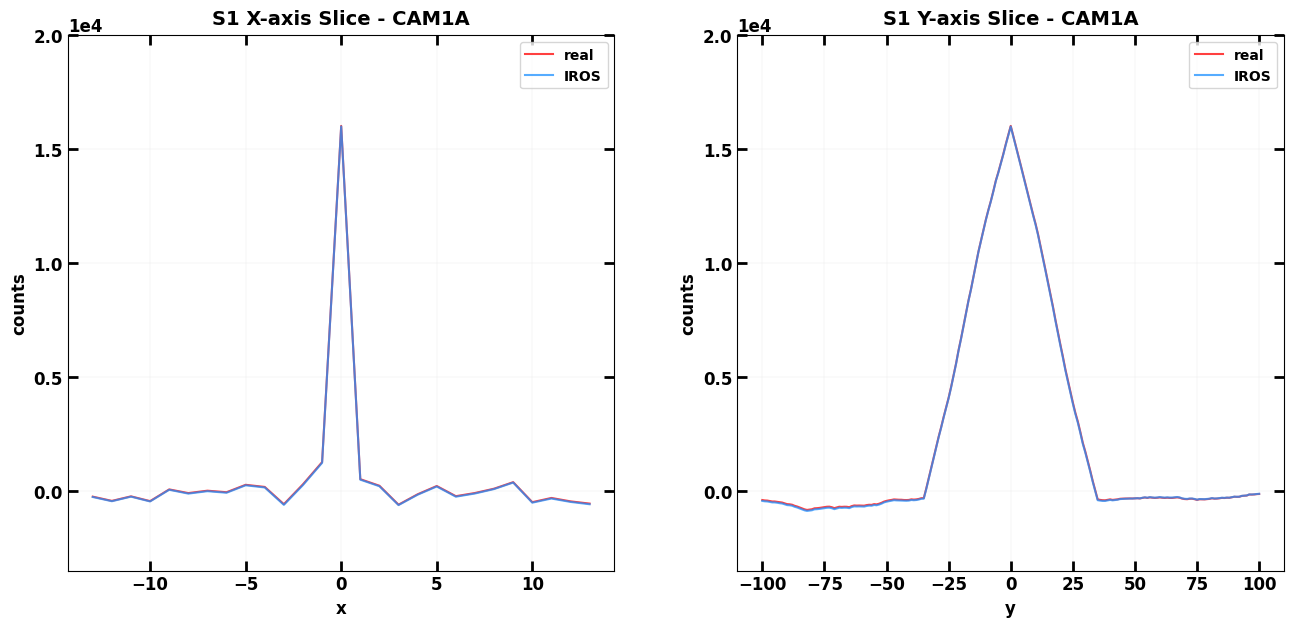

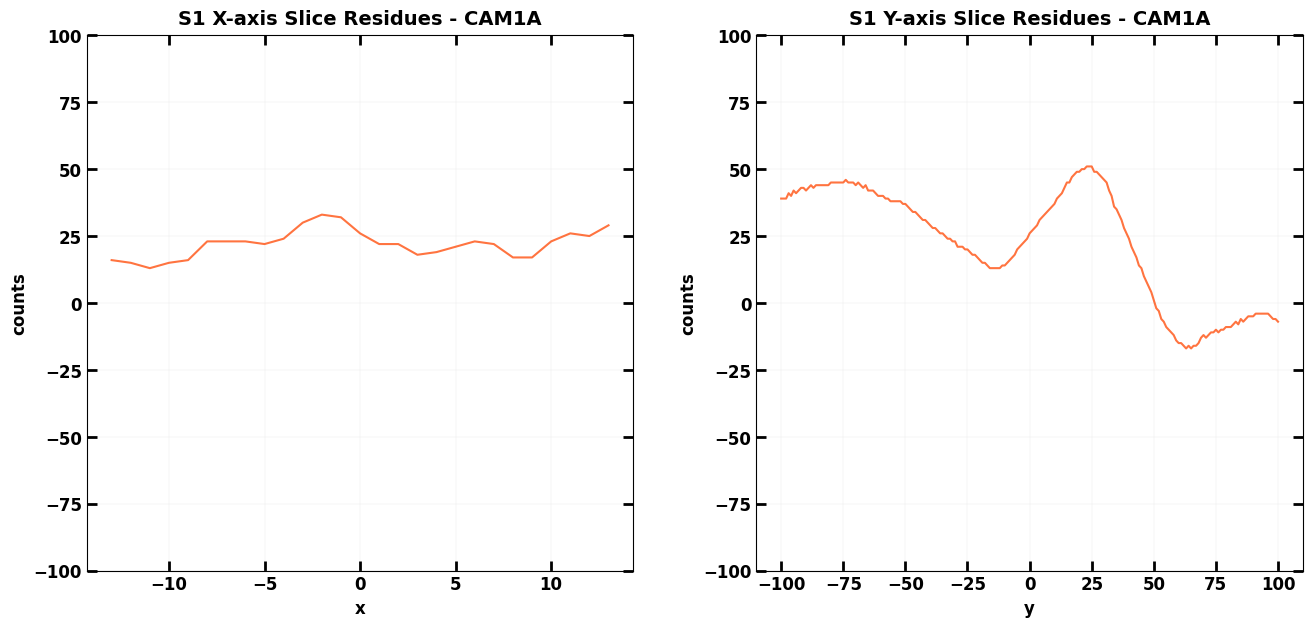

argmax simulated sky: (516, 1502)
argmax IROS sky: (516, 1502)
database pos: (np.int32(754), np.int32(351))


In [8]:
upx, upy = wfm.upscale_f
crp = (int(50 * (1 + upy)), int(10 * (1 + upx / 3)))
_to = 1

for source, y, x in zip(
    database[cam_a]["catalog_name"]["data"][:],
    database[cam_a]["y"]["data"][:],
    database[cam_a]["x"]["data"][:],
):
    enhance_slices(
        sky=[simul_sky_camA, sky_camA],
        label=[("real", "IROS")] * 2,
        pos=argmax(simul_sky_camA), #(y, x),
        crp=crp,
        source=source,
        cameraID=cam_a,
        offsety_first=[(-3500, 20000)] * 2,
        offsety_second=[(-100, 100)] * 2,
        #save_to_first=save_path + "../models.png",
        #save_to_second=save_path + "../res.png",
    )

print(
    f"argmax simulated sky: {argmax(simul_sky_camA)}\n"
    f"argmax IROS sky: {argmax(sky_camA)}\n"
    f"database pos: {database[cam_a]["y"]["data"][0], database[cam_a]["x"]["data"][0]}"
)


## CAM1B
#_to = 1
#
#for source, y, x in zip(
#    database[cam_b]["catalog_name"]["data"][:_to],
#    database[cam_b]["y"]["data"][:_to],
#    database[cam_b]["x"]["data"][:_to],
#):
#    enhance_slices(
#        sky=[simul_sky_camB, sky_camB],
#        label=[("real", "IROS")] * 2,
#        pos=(y, x),
#        crp=crp,
#        source=source,
#        cameraID=cam_b,
#        offsety_first=[(-5000, 95000)] * 2,
#        offsety_second=[(-2500, 2000)] * 2,
#    )
#
#print(
#    f"argmax simulated sky: {argmax(simul_sky_camB)}\n"
#    f"argmax IROS sky: {argmax(sky_camB)}\n"
#    f"database pos: {database[cam_b]["y"]["data"][0], database[cam_b]["x"]["data"][0]}"
#)

- Heatmap

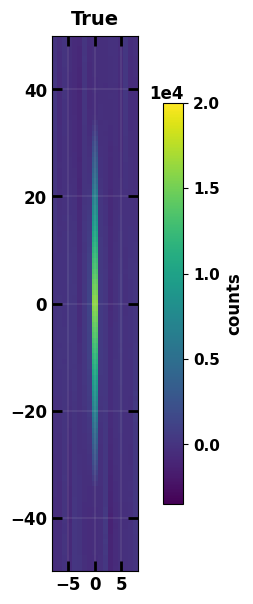

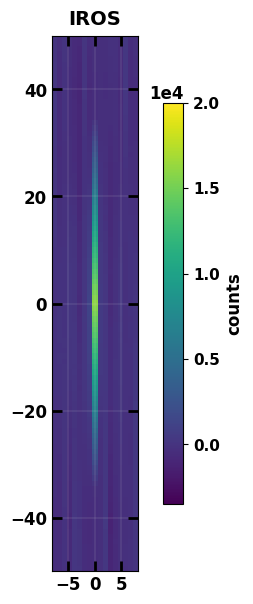

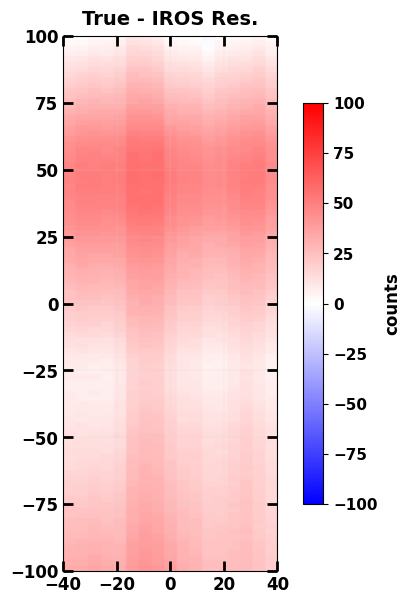

In [9]:
from numpy.typing import NDArray

def upscale(
    data: npt.NDArray,
    upscale_y: int = 1,
    upscale_x: int = 1,
) -> npt.NDArray:
    """
    Upscales a 2D array by repeating elements along each axis and
    by interpolating array values.

    Args:
        data (npt.NDArray): Input 2D array.
        upscale_y (int): Upscaling factor over the y direction.
        upscale_x (int): Upscaling factor over the x direction.

    Returns:
        output (npt.NDArray): Oversampled array.

    Raises:
        ValueError: if upscale factors are not positive integers.
    
    Notes:
        - The array total sum is conserved through linear interpolation.
        - For N-dim arrays, consider using `astropy.nndata.block_replicate()`.
    """
    def _enlarge(
        m: npt.NDArray,
        upscale_f: tuple[int, int],
    ) -> npt.NDArray:
        for i, f in enumerate(upscale_f[::-1]):
            m = np.repeat(m, f, axis=i)
        return m
    
    if not (
        (isinstance(upscale_y, int) and upscale_y > 0) and
        (isinstance(upscale_x, int) and upscale_x > 0)
    ):
        raise ValueError("Upscaling factors must be positive integers.")
    
    upscaling = (upscale_x, upscale_y)
    return _enlarge(data, upscaling) / np.prod(upscaling)


def image_plot(
    arr: NDArray,
    title: str = None,
    xlabel: str = None,
    ylabel: str = None,
    cbarlabel: str = None,
    figsize: tuple[int | float] = (6, 6),
    dpi: int = 100,
    cbarscinot: bool = False,
    cbarloc: str = "right",
    **kwargs,
) -> None:
    """
    Plot the input 2D array.
    """
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    fig.tight_layout()
    fig.dpi = dpi

    img = ax.imshow(arr, origin='lower', **kwargs)
    cbar = fig.colorbar(img, ax=ax, location=cbarloc, shrink=0.75, pad=0.05)
    cbar.ax.tick_params(labelsize=11)
    if cbarlabel: cbar.set_label(cbarlabel, fontsize=12, fontweight='bold')
    if cbarscinot: cbar.formatter.set_powerlimits((-3, 3))

    ax.set_title(title, fontsize=14, pad=8, fontweight='bold')
    ax.set_xlabel(xlabel or "", fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel or "", fontsize=12, fontweight='bold')
    ax.grid(visible=True, color="lightgray", linestyle="-", linewidth=0.2, alpha=0.70)
    ax.tick_params(which='both', direction='in', width=2, length=7 if 'major' else 4)
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    plt.show()


cut = (50, 8)
pos = argmax(simul_sky_camA) # (database[cam_a]["y"]["data"][0], database[cam_a]["x"]["data"][0])

skyA_hm = iros.crop(
    image=sky_camA,
    pos=pos,
    cropping=cut,
)
sim_skyA_hm = iros.crop(
    image=simul_sky_camA,
    pos=pos,
    cropping=cut,
)

image_plot(
    arr=sim_skyA_hm,
    title="True",
    #xlabel="x",
    #ylabel="y",
    cbarlabel="counts",
    cmap="viridis",
    vmin=-3500,
    vmax=20000,
    extent=(-cut[1], cut[1], -cut[0], cut[0]),
    dpi=100,
    cbarscinot=True,
)
image_plot(
    arr=skyA_hm,
    title="IROS",
    #xlabel="x",
    #ylabel="y",
    cbarlabel="counts",
    cmap="viridis",
    vmin=-3500,
    vmax=20000,
    extent=(-cut[1], cut[1], -cut[0], cut[0]),
    dpi=100,
    cbarscinot=True,
)


f_upy, f_upx = 2, 5
image_plot(
    arr=upscale(sim_skyA_hm - skyA_hm, f_upy, f_upx) * np.prod((f_upy, f_upx)),
    title="True - IROS Res.",
    #xlabel="x",
    #ylabel="y",
    cbarlabel="counts",
    cmap="bwr",
    vmin=-100,
    vmax=100,
    extent=(-cut[1] * f_upx, cut[1] * f_upx, -cut[0] * f_upy, cut[0] * f_upy),
    dpi=100,
    cbarscinot=True,
)

In [10]:
from copy import deepcopy
from pandas import DataFrame

from mbloodmoon.io import SimulationDataLoader
from mbloodmoon.mask import CodedMaskCamera
from mbloodmoon.coords import equatorial2shift, shift2angle


def get_catalog_theta(
    data: dict,
    catalogs: tuple[np.recarray],
    sdls: tuple[SimulationDataLoader],
    camera: CodedMaskCamera,
) -> DataFrame:
    """Returns catalog sources respective camera angular coordinates."""
    db = {
        cameraID: deepcopy({
            "theta_x": [],
            "theta_y": [],
        })
        for cameraID in data.keys()
    }

    for sdl, cat, cameraID in zip(
        sdls, catalogs, data.keys(),
    ):
        print(f"# Checking {cameraID.upper()}...")
        for name in data[cameraID]["catalog_name"]["data"]:
            cat_ra = cat.data[cat.data["NAME"] == name]["RA"][0]
            cat_dec = cat.data[cat.data["NAME"] == name]["DEC"][0]
            sx, sy = equatorial2shift(sdl, camera, cat_ra, cat_dec)
            db[cameraID]["theta_x"].append(shift2angle(camera, sx))
            db[cameraID]["theta_y"].append(shift2angle(camera, sy))

    return iros.dict2df(db)



catalog_theta = get_catalog_theta(database, (catalogA, catalogB), (sdlA, sdlB), wfm)

# CAM1A
thetay_cam1a = database[cam_a]["theta_y"]["data"]
thetax_cam1a = database[cam_a]["theta_x"]["data"]

thetay_catalog_cam1a = catalog_theta[cam_a]["theta_y"]
thetax_catalog_cam1a = catalog_theta[cam_a]["theta_x"]

print(
    f"Res theta y: {60 * (thetay_cam1a - thetay_catalog_cam1a)} arcmin\n"
    f"Res theta x: {60 * (thetax_cam1a - thetax_catalog_cam1a)} arcmin"
)

#ly = 1e-2

#iros.plot_sequence(
#    input_sequence=[60 * (thetay_cam1a - thetay_catalog_cam1a), 60 * (thetax_cam1a - thetax_catalog_cam1a)],
#    title=[r"IROS-Cat. Off-axis Angle $\theta_{y}$ Residues - CAM1A", r"IROS-Cat. Off-axis Angle $\theta_{x}$ Residues - CAM1A"],
#    x=[thetay_catalog_cam1a, thetax_catalog_cam1a],
#    xlabel=[r"catalog $\theta_{y}$" + " [deg]", r"catalog $\theta_{x}$" + " [deg]"],
#    ylabel=[r"residues $\Delta\theta_{y}$" + " [arcmin]", r"residues $\Delta\theta_{x}$" + " [arcmin]"],
#    style=["scatter"]*2,
#    offsetx=[(-45, 45)]*2,
#    offsety=[(-ly, ly), (-ly, ly)],
#)

# Checking CAM1A...
# Checking CAM1B...
Res theta y: 0   -375.26661
Name: theta_y, dtype: float64 arcmin
Res theta x: 0   -1850.150032
Name: theta_x, dtype: float64 arcmin


In [ ]:
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt

import mbloodmoon as bm
from mbloodmoon.mask import CodedMaskCamera, codedmask
from mbloodmoon.io import SimulationDataLoader
from mbloodmoon.images import argmax
from mbloodmoon.optim import iros as IROS
from mbloodmoon.types import CoordEquatorial

from _IROS_support import _handle_dirpaths

def run_iros(
    camera: CodedMaskCamera,
    sdlA: SimulationDataLoader,
    sdlB: SimulationDataLoader,
    iterations: int,
    threshold: int | float,
    vignetting: bool,
    psfy: bool,
):
    def callback(i: int, x):
        print(f"on iteration {i}..")
        sources, _ = x
        source1a, source1b = sources
        sx1a, sy1a, f1a, _ = source1a
        sx1b, sy1b, f1b, _ = source1b
        return (sx1a, sy1a, f1a), (sx1b, sy1b, f1b)

    loop = IROS(
        camera=camera,
        sdl_cam1a=sdlA,
        sdl_cam1b=sdlB,
        max_iterations=iterations,
        snr_threshold=threshold,
        vignetting=vignetting,
        psfy=psfy,
    )
    return [callback(i, s) for i, s in enumerate(loop, start=1)]

mask_FITS = "wfm_mask.fits"
skyfield = "IROSDummy"
data_FITS = "catalog_noCXB_1Crab_infdet_2-50keV_1ks"

N_TEST = "BMRESIDUALS_test_s8_upx1y1_detected"

UPX, UPY = 5, 8

mask_path, simul_data, save_path = _handle_dirpaths(
    mask=mask_FITS,
    skyfield=skyfield,
    simul=data_FITS,
    test_name=N_TEST,
)

cam_a = "cam1a"
cam_b = "cam1b"
dataset = "detected"

filepaths = bm.simulation_files(simul_data)
energy_range = (None, None)
s0 = CoordEquatorial(ra=223.438453172364, dec=-22.0306369561417)
s1 = CoordEquatorial(ra=231.465619039524, dec=-24.3850523670622)
s2 = CoordEquatorial(ra=241.426574413659, dec=-26.6219960573764)
s3 = CoordEquatorial(ra=253.284954989872, dec=-28.3032728404397)
s4 = CoordEquatorial(ra=266.4, dec=-28.94)
s5 = CoordEquatorial(ra=266.4, dec=-17.3775096005863)
s6 = CoordEquatorial(ra=266.4, dec=-6.63642699386322)
s7 = CoordEquatorial(ra=266.4, dec=2.68547284486862)
s8 = CoordEquatorial(ra=266.4, dec=10.4607609542733)
coords = (
    s0, s1, s2, s3, s4, s5, s7, s8,
)
assert (s6 not in coords) and (len(coords) == 8)


wfm = codedmask(mask_path, UPX, UPY)
sdlA = bm.simulation(filepaths[cam_a][dataset], energy_range=energy_range, coords=coords)
sdlB = bm.simulation(filepaths[cam_b][dataset], energy_range=energy_range, coords=coords)



from mbloodmoon.coords import shift2pos, equatorial2shift
from mbloodmoon.images import compose

def equatorial2pos(
    sdl: SimulationDataLoader,
    camera: CodedMaskCamera,
    ra: float,
    dec: float,
) -> tuple[int, int]:
    """
    Convert equatorial coordinates (RA/Dec) to sky pixel position.

    Args:
        sdl: SimulationDataLoader containing camera pointings
        camera: A CodedMaskCamera object containing sky shape and binning information.
        ra: Right ascension in degrees [0, 360].
        dec: Declination in degrees [-90, 90].

    Returns:
        Tuple of (row, column) indices in the discrete sky image grid.

    Notes:
        - RA must be normalized to [0, 360) degree range.
    """
    return shift2pos(camera, *equatorial2shift(sdl, camera, ra, dec))

catalogA = bm.simulation(filepaths[cam_a]["sources"])
catalogB = bm.simulation(filepaths[cam_b]["sources"])

ya, xa = equatorial2pos(sdlA, wfm, catalogA.data[-1]["RA"], catalogA.data[-1]["DEC"])
yb, xb = equatorial2pos(sdlB, wfm, catalogB.data[-1]["RA"], catalogB.data[-1]["DEC"])

comp, mapping = compose(
    a=np.zeros(wfm.shape_sky),
    b=np.zeros(wfm.shape_sky),
    strict=False,
)

mapping()


#sources = run_iros(wfm, sdlA, sdlB, 1, 5, True, False)
#
#from mbloodmoon.coords import equatorial2shift
#
#catalogA = bm.simulation(filepaths[cam_a]["sources"])
#sources, equatorial2shift(sdlA, wfm, catalogA.data[-1]["RA"], catalogA.data[-1]["DEC"])
#
#
#from mbloodmoon.optim import model_sky
#from mbloodmoon.images import _upscale, compose
#
#comp, mapping = compose(
#    a=_upscale(model_sky(wfm, *sources[0], True, False), 1, 8),
#    b=_upscale(model_sky(wfm, *sources[1], True, False), 1, 8),
#    strict=False,
#)

KeyboardInterrupt: 

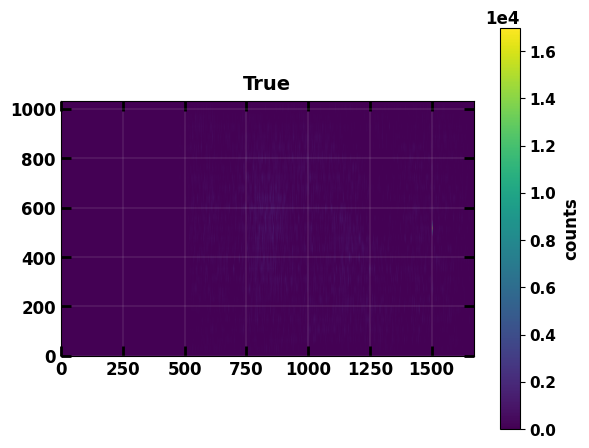

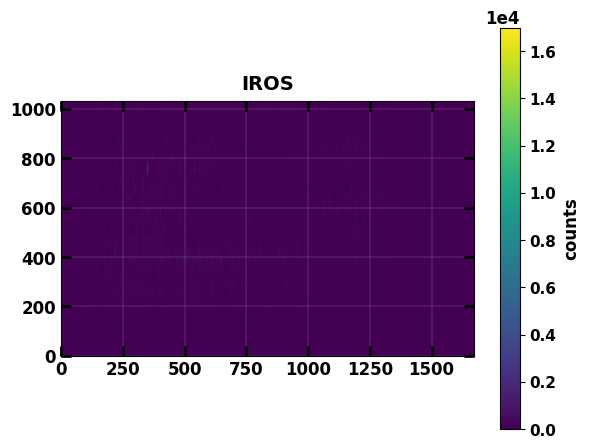

(np.int32(16023),
 np.float64(6411.167000472307),
 np.float64(10815.538367277919),
 np.int32(15997),
 np.float64(-121.12472323850525),
 np.float64(95.39999976197055),
 166.66845262906708,
 2.7506515055996206e-05)

In [15]:
from mbloodmoon.coords import shift2pos, equatorial2shift
from mbloodmoon.optim import model_sky

database["cam1a"], database["cam1b"]



sx, sy, f = database["cam1a"]["shift_x"]["data"][0], database["cam1a"]["shift_y"]["data"][0], database["cam1a"]["fluence"]["data"][0]

row, col = shift2pos(wfm, sx, sy)

sx_from_eq, sy_from_eq = equatorial2shift(sdlA, wfm, catalogA.data[-1]["RA"], catalogA.data[-1]["DEC"])


image_plot(
    arr=simul_sky_camA,
    title="True",
    #xlabel="x",
    #ylabel="y",
    cbarlabel="counts",
    cmap="viridis",
    vmin=0,
    vmax=17000,
    dpi=100,
    cbarscinot=True,
)
image_plot(
    arr=model_sky(wfm, sx, sy, f, True, False),
    title="IROS",
    #xlabel="x",
    #ylabel="y",
    cbarlabel="counts",
    cmap="viridis",
    vmin=0,
    vmax=17000,
    dpi=100,
    cbarscinot=True,
)




s = model_sky(wfm, sx, sy, f, True, False)
simul_sky_camA[*argmax(simul_sky_camA)], s[*argmax(s)], f, sky_camA[*argmax(sky_camA)], sx, sy, sx_from_eq, sy_from_eq

<br>

- Source profile: `reconstructed` vs `detected`

In [14]:
assert False

AssertionError: 

In [ ]:
if 'detected' in N_TEST:
    rec = N_TEST[: -(len('detected') + 1)]
    det = N_TEST
else:
    rec = N_TEST
    det = N_TEST + '_detected'

true_skyA_rec, _ = 

SyntaxError: invalid syntax (2004422045.py, line 8)

: 

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


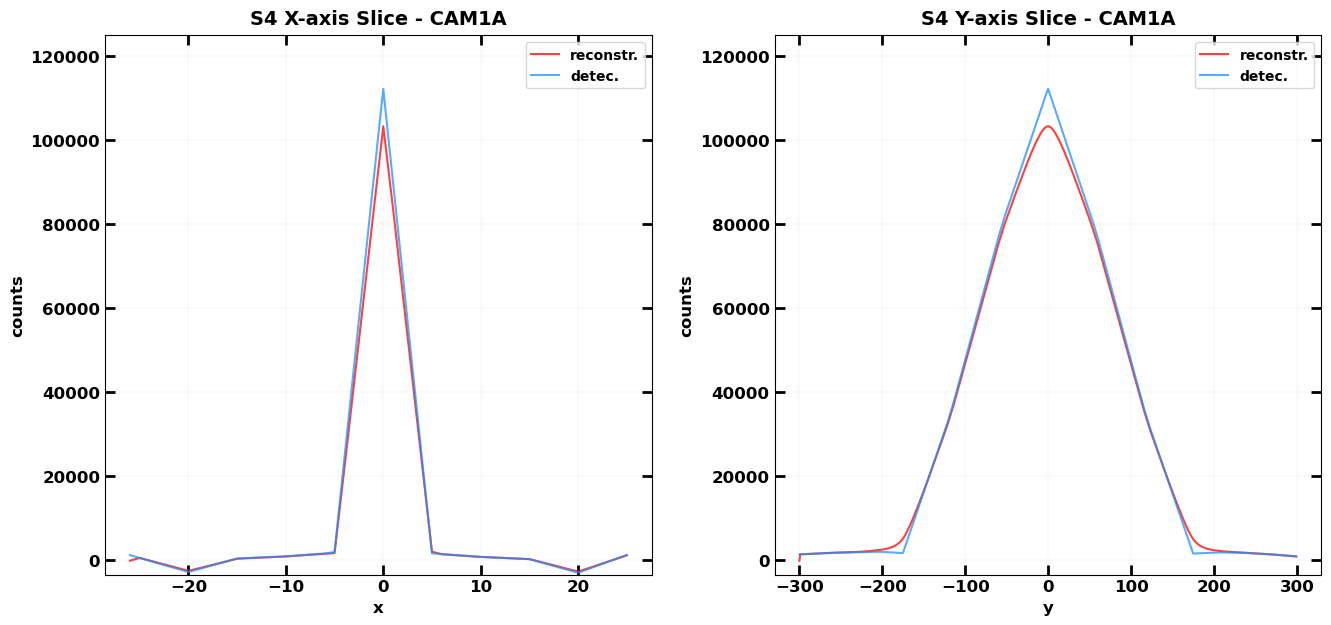

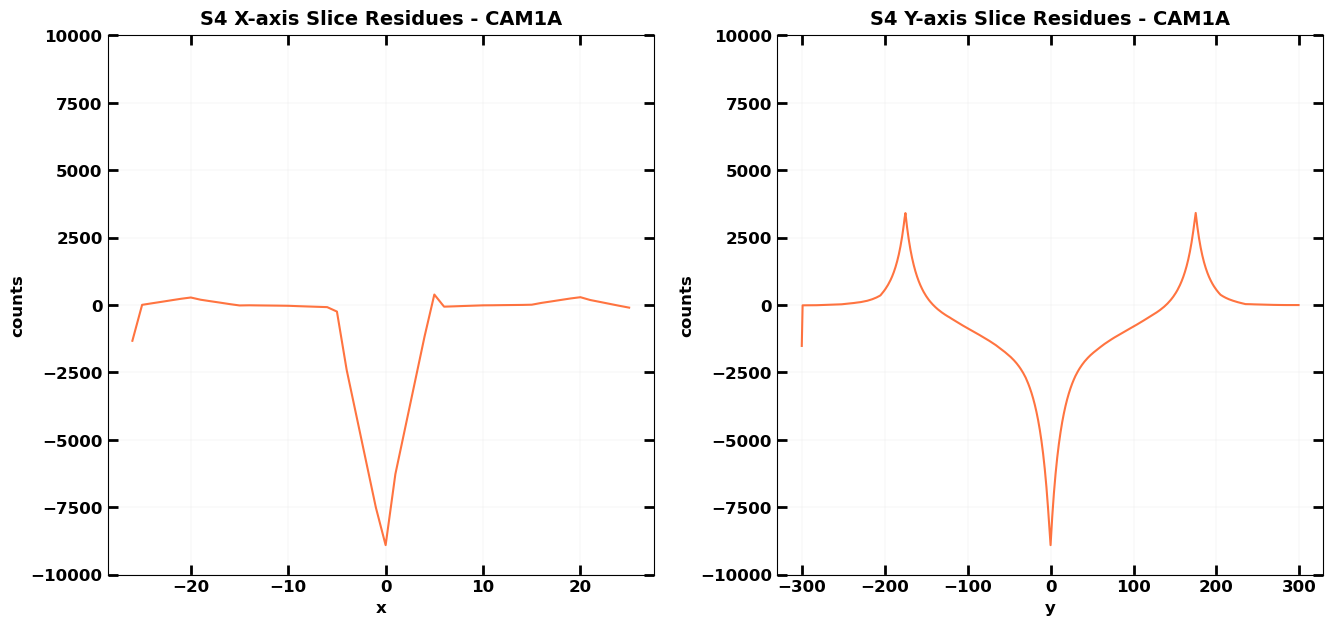

argmax simulated sky: (2584, 4179)
argmax IROS sky: (2584, 4179)



In [ ]:
rec = "test_s4_upx5y5"
det = "test_s4_upx5y5_detected"

iros_skyA_reconstructed, _ = iros.load_sky(save_path + f"../test_s4_upx5y5/OUTsky_IROS_CAM1A_TEST_{rec}.fits")
iros_skyA_detected, _ = iros.load_sky(save_path + f"OUTsky_IROS_CAM1A_TEST_{det}.fits")

enhance_slices(
    sky=[iros_skyA_reconstructed, iros_skyA_detected],
    label=[("reconstr.", "detec.")] * 2,
    pos=argmax(sky_camA),
    crp=crp,
    source=source,
    cameraID=cam_a,
    offsety_first=[(-3500, 125000)] * 2,
    offsety_second=[(-10000, 10000)] * 2,
)

print(
    f"argmax simulated sky: {argmax(iros_skyA_reconstructed)}\n"
    f"argmax IROS sky: {argmax(iros_skyA_detected)}\n"
)

**PSFY Kernel**

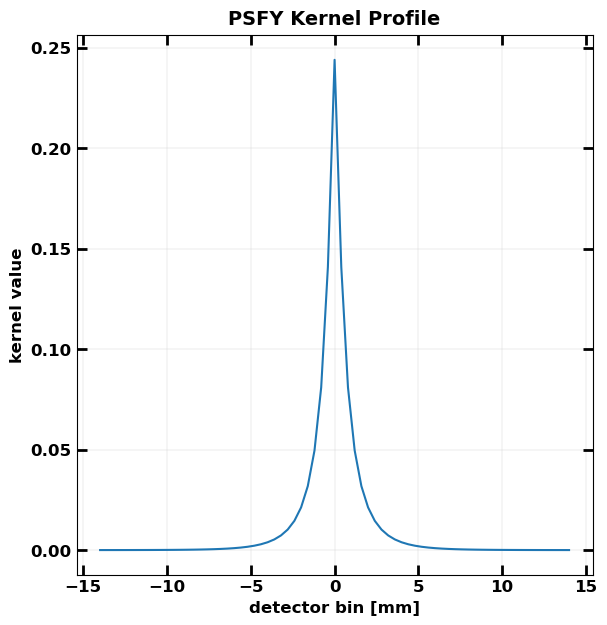

(array([-14. , -13.6, -13.2, -12.8, -12.4, -12. , -11.6, -11.2, -10.8,
        -10.4]),
 array([10.4, 10.8, 11.2, 11.6, 12. , 12.4, 12.8, 13.2, 13.6, 14. ]))

In [ ]:
from mbloodmoon.mask import CodedMaskCamera
from mbloodmoon.optim import _wfm_psfy

def _convolution_kernel_psfy(camera: CodedMaskCamera) -> npt.NDArray:
    """
    Returns PSF convolution kernel.
    At present, it ignores the `x` direction, since PSF characteristic lenght is much shorter
    than typical bin size, even at moderately large upscales.

    Args:
        camera: a CodedMaskCamera object.

    Returns:
        A column array convolution kernel.
    """
    # we take a whole slit to have a good kernel spatial extension
    slit = camera.mdl["slit_deltay"]
    # to define the kernel, we only need an array with the same binning step
    num = int(2 * slit * camera.upscale_f.y / camera.mdl["mask_deltay"]) + 1
    bins = np.linspace(-slit, slit, num)
    kernel = _wfm_psfy(bins).reshape(len(bins), -1)
    kernel = kernel / np.sum(kernel)
    return kernel


mask_FITS = "wfm_mask.fits"
mask_path = "/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations/" + mask_FITS
#mask_path = "/mnt/d/PhD_AASS/Coding/Images_fits/" + mask_FITS
cam = codedmask(mask_path, upscale_y=1)

kernel = _convolution_kernel_psfy(cam)

slit = cam.mdl["slit_deltay"]
num = int(2 * slit * cam.upscale_f.y / cam.mdl["mask_deltay"]) + 1
bins = np.linspace(-slit, slit, num)
assert (abs(bins[1] - bins[0]) - cam.mdl["mask_deltay"] / cam.upscale_f.y) < 1e-10


fig, ax = plt.subplots(1, 1, figsize=(6, 6))
fig.tight_layout()
ax.plot(bins, kernel)
ax.set_xlabel("detector bin [mm]", fontsize=12, fontweight='bold')
ax.set_ylabel("kernel value", fontsize=12, fontweight='bold')
ax.set_title("PSFY Kernel Profile", fontsize=14, pad=8, fontweight='bold')
ax.grid(visible=True, color="lightgray", linestyle="-", linewidth=0.3)
ax.tick_params(which='both', direction='in', width=2, length=7 if 'major' else 4)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
plt.show()

bins[:10], bins[-10:]

In [ ]:
from pathlib import Path
import numpy as np
from mbloodmoon.coords import angle2shift
from mbloodmoon.mask import CodedMaskCamera, codedmask
from mbloodmoon.optim import apply_vignetting

def test_linear_vignetting(
    camera: CodedMaskCamera,
    thetax: float,
    thetay: float,
    norm: bool = True,
) -> None:
    """Tests if vignetting is a linear operation."""

    sx, sy = map(lambda x: angle2shift(camera, x), (thetax, thetay))
    gamma = 2

    # V(gamma * x)
    V_gamma_mask = apply_vignetting(
        camera=camera,
        shadowgram=gamma * camera.mask,
        shift_x=sx,
        shift_y=sy,
    )
    if norm: V_gamma_mask /= V_gamma_mask.sum()  # normalisation

    # gamma * V(x)
    gamma_V_mask = gamma * apply_vignetting(
        camera=camera,
        shadowgram=camera.mask,
        shift_x=sx,
        shift_y=sy,
    )
    if norm: gamma_V_mask /= gamma_V_mask.sum()  # normalisation

    print(
        f"std[V(gamma * x) - gamma * V(x)]: {np.std(V_gamma_mask - gamma_V_mask)}\n"
    )
    return V_gamma_mask, gamma_V_mask




UPX, UPY = 1, 1

mask_FITS = "wfm_mask.fits"
wfm = codedmask("/mnt/d/PhD_AASS/Coding/Images_fits/" + mask_FITS, UPX, UPY)

thetax = 10
thetay = 0
V_gamma_mask, gamma_V_mask = test_linear_vignetting(wfm, thetax, thetay)

V_gamma_mask, gamma_V_mask, (V_gamma_mask - gamma_V_mask).min(), (V_gamma_mask - gamma_V_mask).max()

std[V(gamma * x) - gamma * V(x)]: 8.243089209555703e-08



(array([[6.76081876e-06, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 6.76081876e-06],
        [6.76081876e-06, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 6.76081876e-06],
        [6.76081876e-06, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 6.76081876e-06],
        ...,
        [7.13842799e-06, 6.76081876e-06, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 6.76081876e-06],
        [7.13842799e-06, 6.76081876e-06, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 6.76081876e-06],
        [7.13842799e-06, 6.76081876e-06, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 6.76081876e-06]],
       shape=(650, 1040)),
 array([[6.65856707e-06, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 6.65856707e-06],
        [6.65856707e-06, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 6.65856707e-06],